<a href="https://colab.research.google.com/github/anishkr-sahu/Genai/blob/main/Huggingface_day_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Text-to-image generation using stable diffusion and diffusers

In [1]:
# install diffusers from hugging face hub
!pip install diffusers transformers accelerate

In [2]:
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import torch

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
!pip show torch

Name: torch
Version: 2.11.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: cuda-bindings, cuda-toolkit, filelock, fsspec, jinja2, networkx, nvidia-cudnn-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvshmem-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchdata, torchvision


In [4]:
model_id1 = "dreamlike-art/dreamlike-photoreal-1.0"
model_id2 = "stabilityai/stable-diffusion-3.5-large"

In [6]:
pipe = StableDiffusionPipeline.from_pretrained(model_id1, torch_dtype=torch.float16, use_safetensors=False)
pipe = pipe.to("cuda")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [7]:
prompt =""" draw spiderman picture"""

In [9]:
image = pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

[prompt]:  draw spiderman picture


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

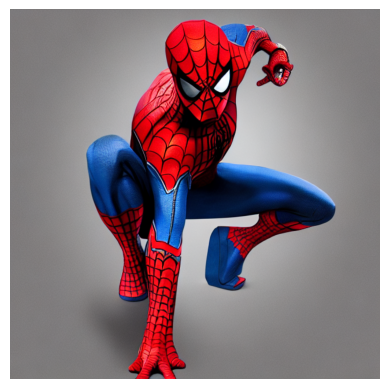

In [10]:
print("[prompt]:", prompt)
plt.imshow(image);
plt.axis('off')

  0%|          | 0/50 [00:00<?, ?it/s]

[prompt]:  draw spiderman picture


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

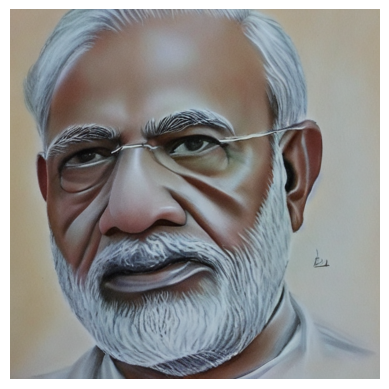

In [11]:
prompt2 = """ draw narendra modi picture"""
image = pipe(prompt2).images[0]
print("[prompt]:", prompt)
plt.imshow(image);
plt.axis('off')

Enter the prompt: draw batman picture


  0%|          | 0/50 [00:00<?, ?it/s]

[prompt]: draw batman picture


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

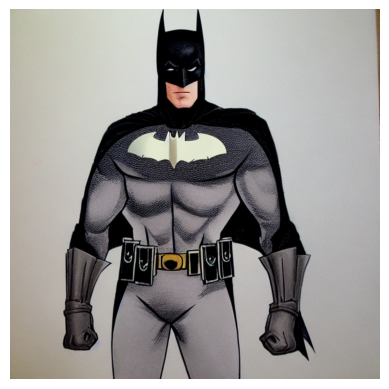

In [12]:
prompt = input("Enter the prompt: ")
image = pipe(prompt).images[0]
print("[prompt]:", prompt)
plt.imshow(image);
plt.axis('off')

Text-to-speech


In [13]:
from transformers import pipeline

In [14]:
text = "Python is a high-level, general purpose programming language"
pipe = pipeline("text-to-speech", model="suno/bark-small", device="cuda")
output = pipe(text)

config.json:   0%|          | 0.00/8.80k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.68GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/542 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.68GB            

...

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.92M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

speaker_embeddings_path.json:   0%|          | 0.00/61.1k [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'min_eos_p', 'return_dict_in_generate'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=768) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'return_dict_in_generate'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentatio

In [16]:
output  # numpy array ko audio  mai convert krna chahte hai toa

{'audio': array([7.9752976e-04, 7.1924669e-04, 1.4533149e-03, ..., 6.1317056e-05,
        6.5027227e-05, 6.9010872e-05], dtype=float32),
 'sampling_rate': 24000}

In [15]:
from IPython.display import Audio
Audio(output['audio'], rate=output["sampling_rate"])